In [1]:
import os
import yaml
import pymongo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from scipy.signal import butter, lfilter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Φόρτωση ρυθμίσεων και Σύνδεση στη MongoDB
config_path = os.path.join(os.getcwd(), "config.yml")
with open(config_path, 'r', encoding='utf-8') as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

client = pymongo.MongoClient(config["client"])
db = client[config["db"]]
coll = db[config["col"]]

# Φόρτωση Δεδομένων
cursor = coll.find({})
df_list = []

for doc in tqdm(cursor, desc="Φόρτωση Δεδομένων"):
    df = pd.DataFrame(doc['data'])
    df['gesture_id'] = doc['gesture_id']
    df['user'] = doc['user'].lower()
    df_list.append(df)

print(f"Φορτώθηκαν {len(df_list)} αρχεία/καταγραφές.")
sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']

Φόρτωση Δεδομένων: 0it [00:00, ?it/s]

Φορτώθηκαν 15 αρχεία/καταγραφές.


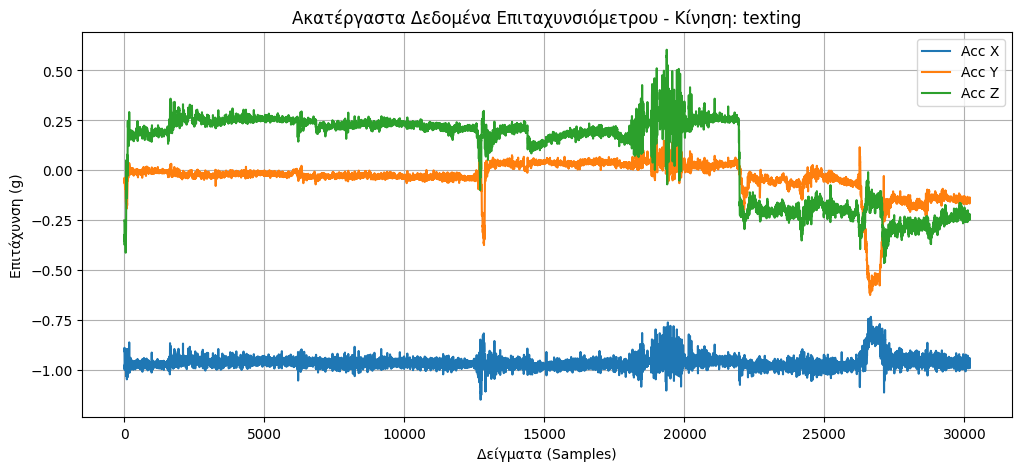

In [2]:
# Επιλέγουμε ένα DataFrame της λίστας για οπτικοποίηση
sample_df = df_list[13]
label = sample_df['gesture_id'].iloc[13]

plt.figure(figsize=(12, 5))
plt.plot(sample_df['acc_x'], label='Acc X')
plt.plot(sample_df['acc_y'], label='Acc Y')
plt.plot(sample_df['acc_z'], label='Acc Z')
plt.title(f"Ακατέργαστα Δεδομένα Επιταχυνσιόμετρου - Κίνηση: {label}")
plt.xlabel("Δείγματα (Samples)")
plt.ylabel("Επιτάχυνση (g)")
plt.legend()
plt.grid(True)
plt.show()


 Έλεγχος για Κενές Τιμές (Missing Values)
Δεν βρέθηκαν κενές τιμές στα δεδομένα μας.


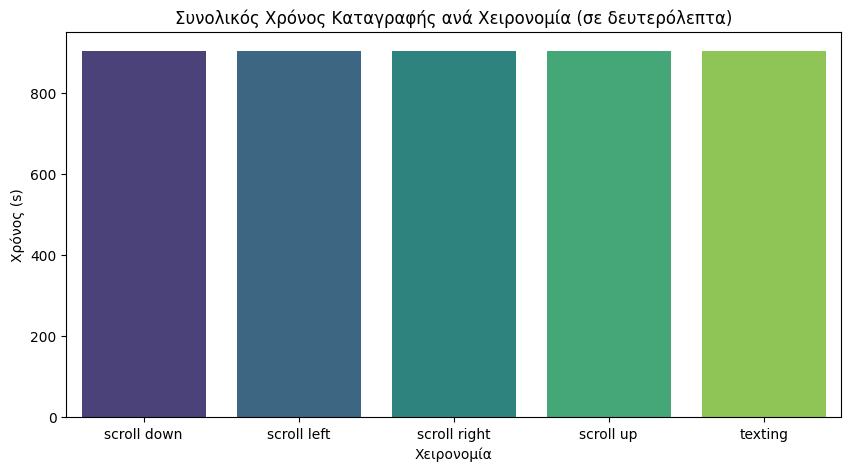

In [3]:
print("\n Έλεγχος για Κενές Τιμές (Missing Values)")
missing_found = False
for i, df in enumerate(df_list):
    if df.isnull().sum().sum() > 0:
        print(f"Βρέθηκαν κενές τιμές στο αρχείο {i}.")
        df.dropna(inplace=True)
        missing_found = True
if not missing_found:
    print("Δεν βρέθηκαν κενές τιμές στα δεδομένα μας.")

time_per_class = {}
for df in df_list:
    label = df['gesture_id'].iloc[0]
    duration = len(df) / 100.0 # 100Hz
    time_per_class[label] = time_per_class.get(label, 0) + duration

plt.figure(figsize=(10, 5))
labels = list(time_per_class.keys())
values = list(time_per_class.values())
sns.barplot(x=labels, y=values, hue=labels, palette="viridis", legend=False)
plt.title("Συνολικός Χρόνος Καταγραφής ανά Χειρονομία (σε δευτερόλεπτα)")
plt.xlabel("Χειρονομία")
plt.ylabel("Χρόνος (s)")
plt.show()

 Time vs Amplitude Plot (Έλεγχος Ορθότητας Συλλογής)


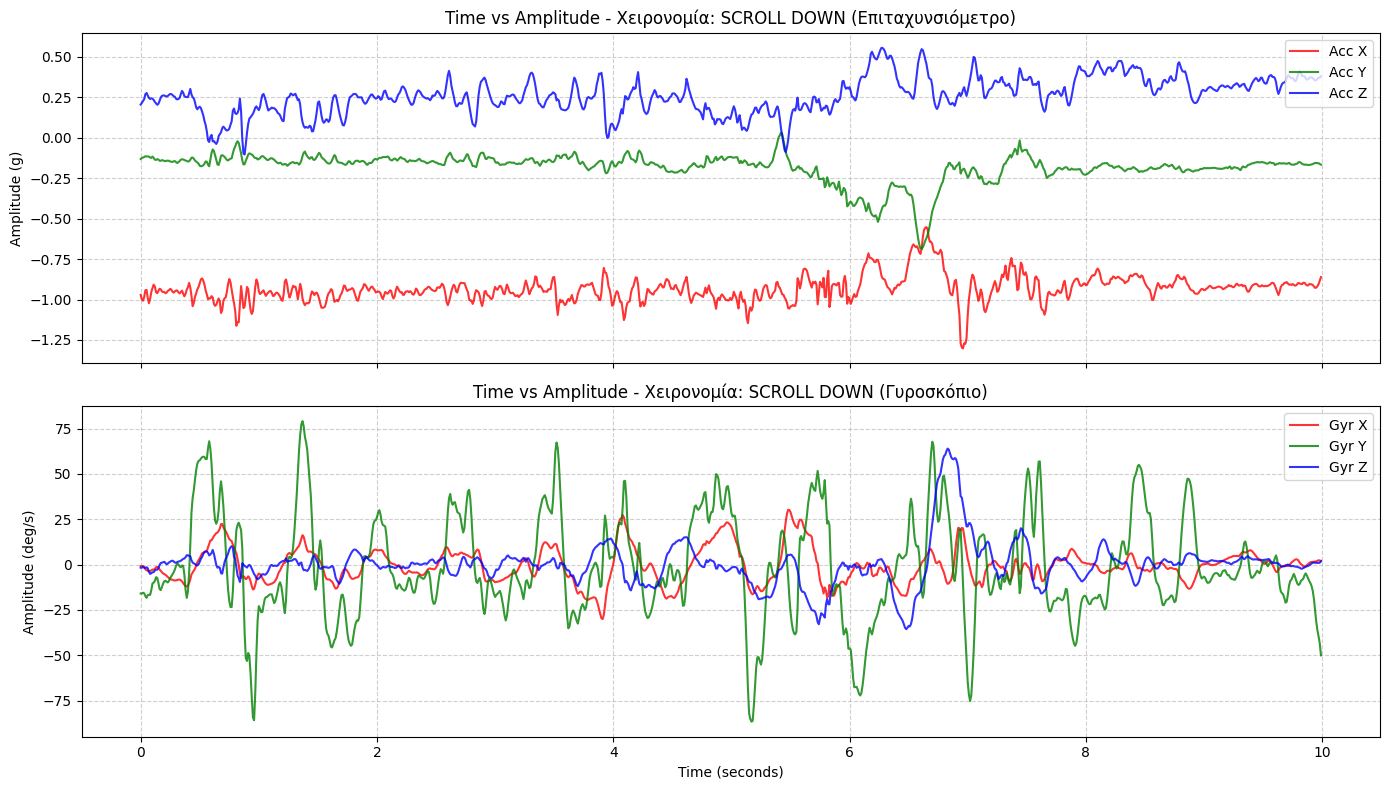

In [4]:
import numpy as np
import matplotlib.pyplot as plt

print(" Time vs Amplitude Plot (Έλεγχος Ορθότητας Συλλογής)")

sample_df = df_list[0]
gesture_name = sample_df['gesture_id'].iloc[0]

#  Καθορισμός Ανάλυσης (Resolution)
# κρατάμε μόνο τα πρώτα 10 δευτερόλεπτα. Στα 100Hz, αυτό σημαίνει 10 * 100 = 1000 δείγματα.
duration_sec = 10
samples_to_plot = int(duration_sec * 100)
plot_df = sample_df.iloc[:samples_to_plot]

#  Δημιουργία του πραγματικού άξονα χρόνου (σε δευτερόλεπτα)
# Διαιρούμε το index με το 100 (συχνότητα δειγματοληψίας)
time_axis = np.arange(len(plot_df)) / 100.0

# Δημιουργία Γραφήματος με 2 Subplots (Ένα για Επιταχυνσιόμετρο, ένα για Γυροσκόπιο)
# Χρησιμοποιούμε 2 γραφήματα γιατί το πλάτος (amplitude) τους έχει διαφορετικές μονάδες μέτρησης (g vs deg/s)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Γράφημα 1: Επιταχυνσιόμετρο (Accelerometer)
ax1.plot(time_axis, plot_df['acc_x'], label='Acc X', color='red', alpha=0.8)
ax1.plot(time_axis, plot_df['acc_y'], label='Acc Y', color='green', alpha=0.8)
ax1.plot(time_axis, plot_df['acc_z'], label='Acc Z', color='blue', alpha=0.8)
ax1.set_title(f"Time vs Amplitude - Χειρονομία: {gesture_name.upper()} (Επιταχυνσιόμετρο)")
ax1.set_ylabel("Amplitude (g)")
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Γράφημα 2: Γυροσκόπιο (Gyroscope)
ax2.plot(time_axis, plot_df['gyr_x'], label='Gyr X', color='red', alpha=0.8)
ax2.plot(time_axis, plot_df['gyr_y'], label='Gyr Y', color='green', alpha=0.8)
ax2.plot(time_axis, plot_df['gyr_z'], label='Gyr Z', color='blue', alpha=0.8)
ax2.set_title(f"Time vs Amplitude - Χειρονομία: {gesture_name.upper()} (Γυροσκόπιο)")
ax2.set_ylabel("Amplitude (deg/s)")
ax2.set_xlabel("Time (seconds)")
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [5]:
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)

fs = 100.0
cutoff = 5.0
for df in df_list:
    for col in sensor_cols:
        df[col] = butter_lowpass_filter(df[col], cutoff, fs)

print("\nΤο φίλτρο 5Hz Low-pass εφαρμόστηκε επιτυχώς.")


Το φίλτρο 5Hz Low-pass εφαρμόστηκε επιτυχώς.


In [6]:
import numpy as np

window_size = 200 # 2 δευτερόλεπτα
overlap = 100     # 50% επικάλυψη

X_features_list = []
y_list = []
user_list = []

for df in df_list:
    gesture = df['gesture_id'].iloc[0]
    user = df['user'].iloc[0]
    
    for start in range(0, len(df) - window_size, overlap):
        window = df[sensor_cols].iloc[start:start+window_size]
        
        window_features = []
        
        #Βασικά Στατιστικά, Skewness (Ασυμμετρία) & Kurtosis (Κύρτωση) ανά άξονα
        for col in sensor_cols:
            window_features.extend([
                window[col].mean(), 
                window[col].std(), 
                window[col].max(), 
                window[col].min(),
                window[col].skew(),  
                window[col].kurt()   
 
            ])
        
        # Signal-Magnitude Area (SMA)
        # Υπολογισμός συνολικής ενέργειας κίνησης για Επιταχυνσιόμετρο και Γυροσκόπιο
        sma_acc = (np.abs(window['acc_x']) + np.abs(window['acc_y']) + np.abs(window['acc_z'])).sum() / window_size
        sma_gyr = (np.abs(window['gyr_x']) + np.abs(window['gyr_y']) + np.abs(window['gyr_z'])).sum() / window_size
        window_features.extend([sma_acc, sma_gyr])
        
        #Correlation (Συσχέτιση Pearson) μεταξύ των αξόνων
        # Επιταχυνσιόμετρο
        corr_acc_xy = window['acc_x'].corr(window['acc_y'])
        corr_acc_xz = window['acc_x'].corr(window['acc_z'])
        corr_acc_yz = window['acc_y'].corr(window['acc_z'])
        
        # Γυροσκόπιο
        corr_gyr_xy = window['gyr_x'].corr(window['gyr_y'])
        corr_gyr_xz = window['gyr_x'].corr(window['gyr_z'])
        corr_gyr_yz = window['gyr_y'].corr(window['gyr_z'])
        
        window_features.extend([
            corr_acc_xy, corr_acc_xz, corr_acc_yz,
            corr_gyr_xy, corr_gyr_xz, corr_gyr_yz
        ])
        
        window_features = np.nan_to_num(window_features).tolist()
        
        X_features_list.append(window_features)
        y_list.append(gesture)
        user_list.append(user)

X = np.array(X_features_list)
y = np.array(y_list)
users = np.array(user_list)

print(f"\nΣυνολικά Παράθυρα: {X.shape[0]}")
print(f" Χαρακτηριστικά (Features) ανά Παράθυρο: {X.shape[1]}")


Συνολικά Παράθυρα: 4501
 Χαρακτηριστικά (Features) ανά Παράθυρο: 44


In [7]:
# Split ανά άτομο
train_users = ['alexis', 'mitsos']
test_users = ['mpakas']

train_idx = np.isin(users, train_users)
test_idx = np.isin(users, test_users)

X_train = X[train_idx]
y_train = y[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dimensionality Reduction (PCA - Διατήρηση 95% της διακύμανσης)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nPrincipal Component Analysis (PCA) ")
print(f"Αρχικές Διαστάσεις (Features): {X_train_scaled.shape[1]}")
print(f"Διαστάσεις μετά το PCA: {X_train_pca.shape[1]} (Κρατήσαμε το 95% της πληροφορίας)")


Principal Component Analysis (PCA) 
Αρχικές Διαστάσεις (Features): 44
Διαστάσεις μετά το PCA: 23 (Κρατήσαμε το 95% της πληροφορίας)



 Βελτιστοποίηση με GridSearchCV
Καλύτερες παράμετροι: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

 Τελική Αναφορά Βελτιστοποιημένου Μοντέλου (Feature Engineering + PCA)
              precision    recall  f1-score   support

 scroll down       0.95      0.12      0.22       300
 scroll left       0.00      0.00      0.00       300
scroll right       0.00      0.00      0.00       300
   scroll up       0.55      0.23      0.33       301
     texting       0.22      0.98      0.36       300

    accuracy                           0.27      1501
   macro avg       0.34      0.27      0.18      1501
weighted avg       0.34      0.27      0.18      1501



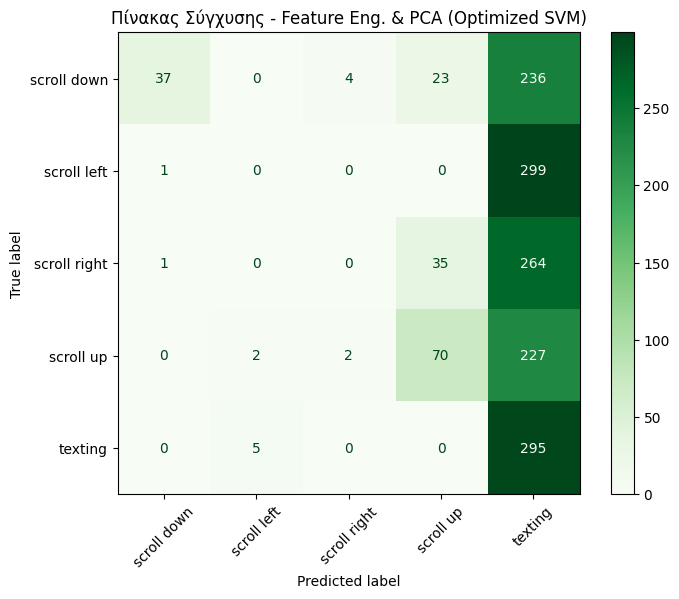


 Εκπαίδευση και Βελτιστοποίηση με Random Forest
Καλύτερες παράμετροι (Random Forest): {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

 Τελική Αναφορά Βελτιστοποιημένου Μοντέλου (Random Forest) 
              precision    recall  f1-score   support

 scroll down       0.55      0.05      0.10       300
 scroll left       0.00      0.00      0.00       300
scroll right       0.00      0.00      0.00       300
   scroll up       0.47      0.34      0.40       301
     texting       0.20      0.77      0.31       300

    accuracy                           0.23      1501
   macro avg       0.24      0.23      0.16      1501
weighted avg       0.24      0.23      0.16      1501



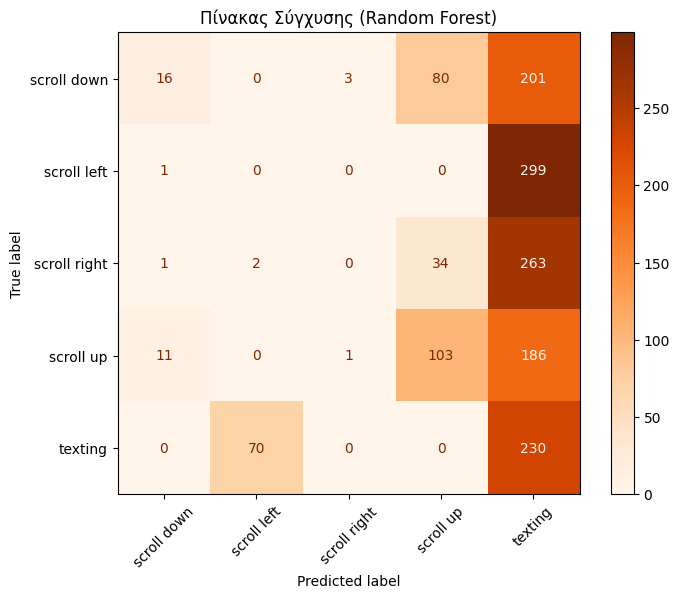

In [8]:
print("\n Βελτιστοποίηση με GridSearchCV")
param_grid = {

    'C': [0.1, 1, 10, 100],

    'kernel': ['linear', 'rbf'],

    'gamma': ['scale', 'auto']

}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_pca, y_train)

print(f"Καλύτερες παράμετροι: {grid_search.best_params_}")
best_clf = grid_search.best_estimator_
y_pred_opt = best_clf.predict(X_test_pca)
print("\n Τελική Αναφορά Βελτιστοποιημένου Μοντέλου (Feature Engineering + PCA)")
print(classification_report(y_test, y_pred_opt, zero_division=0))

# Τελικός Πίνακας Σύγχυσης

cm_opt = confusion_matrix(y_test, y_pred_opt)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=best_clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_opt.plot(cmap=plt.cm.Greens, ax=ax)
plt.title("Πίνακας Σύγχυσης - Feature Eng. & PCA (Optimized SVM)")
plt.xticks(rotation=45)
plt.show()

from sklearn.ensemble import RandomForestClassifier

print("\n Εκπαίδευση και Βελτιστοποίηση με Random Forest")

# Ορίζουμε τις παραμέτρους για το δάσος (πλήθος δέντρων, βάθος κλπ)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train_pca, y_train)

print(f"Καλύτερες παράμετροι (Random Forest): {grid_search_rf.best_params_}")
best_rf_clf = grid_search_rf.best_estimator_

# Πρόβλεψη και Αξιολόγηση
y_pred_rf = best_rf_clf.predict(X_test_pca)
print("\n Τελική Αναφορά Βελτιστοποιημένου Μοντέλου (Random Forest) ")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Τελικός Πίνακας Σύγχυσης 
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=best_rf_clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(cmap=plt.cm.Oranges, ax=ax)
plt.title("Πίνακας Σύγχυσης (Random Forest)")
plt.xticks(rotation=45)
plt.show()

Mixed Users - Feature Engineering

Εκπαίδευση με SVM (Mixed Users - Features)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Καλύτερες παράμετροι: {'C': 100, 'kernel': 'rbf'}

 Τελική Αναφορά Βελτιστοποιημένου Μοντέλου (Mixed Users - SVM)
              precision    recall  f1-score   support

 scroll down       0.95      0.93      0.94       190
 scroll left       0.92      0.94      0.93       187
scroll right       0.94      0.96      0.95       184
   scroll up       0.95      0.94      0.95       158
     texting       0.95      0.95      0.95       182

    accuracy                           0.94       901
   macro avg       0.94      0.94      0.94       901
weighted avg       0.94      0.94      0.94       901



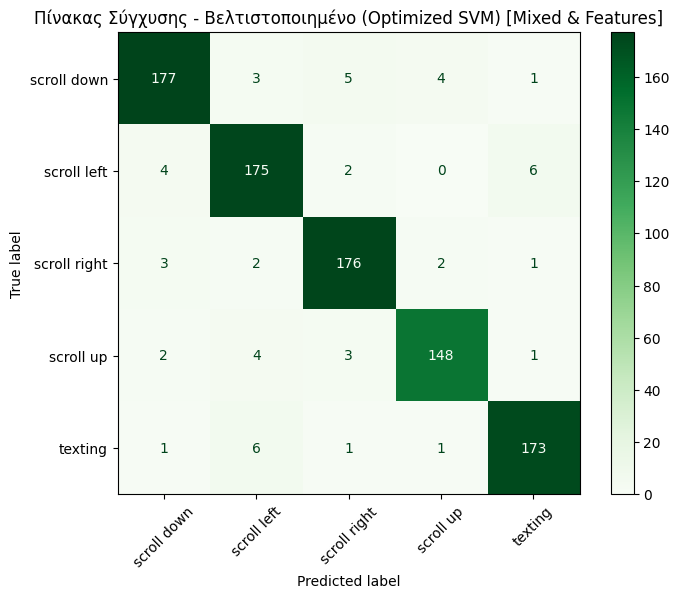

 
Εκπαίδευση με Random Forest 
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Καλύτερες παράμετροι (Random Forest): {'max_depth': None, 'n_estimators': 200, 'random_state': 42}

 Αναφορά Μοντέλου Random Forest (Mixed Users - Features) 
              precision    recall  f1-score   support

 scroll down       0.86      0.81      0.83       190
 scroll left       0.83      0.91      0.87       187
scroll right       0.93      0.95      0.94       184
   scroll up       0.83      0.88      0.86       158
     texting       0.96      0.86      0.90       182

    accuracy                           0.88       901
   macro avg       0.88      0.88      0.88       901
weighted avg       0.88      0.88      0.88       901



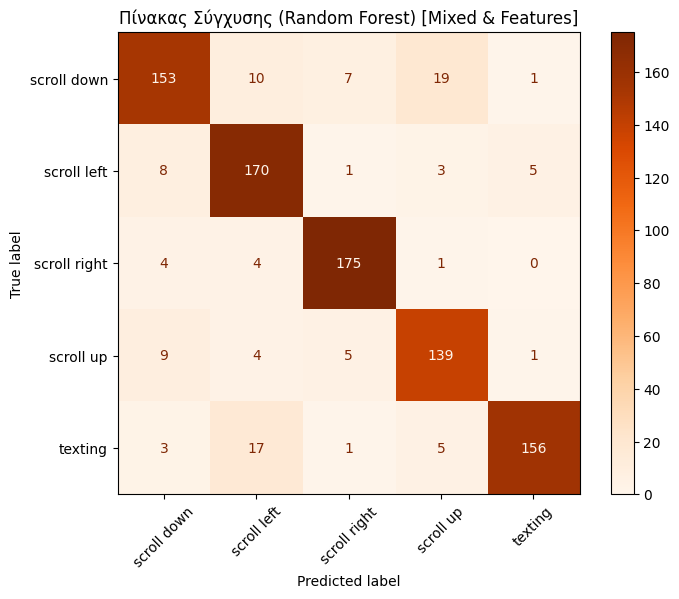

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("Mixed Users - Feature Engineering")


# Ανακατεύουμε όλα τα δεδομένα (Mitsos, Mpakas, Alexis)
X_train_mix, X_test_mix, y_train_mix, y_test_mix = train_test_split(
    X, y, test_size=0.20, shuffle=True, random_state=42
)

# Κανονικοποίηση 
scaler_mix = StandardScaler()
X_train_mix_scaled = scaler_mix.fit_transform(X_train_mix)
X_test_mix_scaled = scaler_mix.transform(X_test_mix)

# PCA 
pca_mix = PCA(n_components=0.95)
X_train_mix_pca = pca_mix.fit_transform(X_train_mix_scaled)
X_test_mix_pca = pca_mix.transform(X_test_mix_scaled)


# SVM
print("\nΕκπαίδευση με SVM (Mixed Users - Features)")
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_mix_pca, y_train_mix)

print(f"Καλύτερες παράμετροι: {grid_search.best_params_}")
best_clf = grid_search.best_estimator_

y_pred_opt = best_clf.predict(X_test_mix_pca)
print("\n Τελική Αναφορά Βελτιστοποιημένου Μοντέλου (Mixed Users - SVM)")
print(classification_report(y_test_mix, y_pred_opt, zero_division=0))

cm_opt = confusion_matrix(y_test_mix, y_pred_opt)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=best_clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_opt.plot(cmap=plt.cm.Greens, ax=ax)
plt.title("Πίνακας Σύγχυσης - Βελτιστοποιημένο (Optimized SVM) [Mixed & Features]")
plt.xticks(rotation=45)
plt.show()


#Random Forest
print(" \nΕκπαίδευση με Random Forest ")

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'random_state': [42]
}

# Βελτιστοποίηση με GridSearchCV
grid_search_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_mix_pca, y_train_mix)

print(f"Καλύτερες παράμετροι (Random Forest): {grid_search_rf.best_params_}")
best_rf_clf = grid_search_rf.best_estimator_

# Πρόβλεψη και Αξιολόγηση
y_pred_rf = best_rf_clf.predict(X_test_mix_pca)
print("\n Αναφορά Μοντέλου Random Forest (Mixed Users - Features) ")
print(classification_report(y_test_mix, y_pred_rf, zero_division=0))

# Πίνακας Σύγχυσης 
cm_rf = confusion_matrix(y_test_mix, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=best_rf_clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(cmap=plt.cm.Oranges, ax=ax)
plt.title("Πίνακας Σύγχυσης (Random Forest) [Mixed & Features]")
plt.xticks(rotation=45)
plt.show()